In [1]:
# Importing common libraries from the Meep Examples

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 

%matplotlib inline 


Keeping it simple, seeing if I can do a unit cell photonic crystal with meep first: 

     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


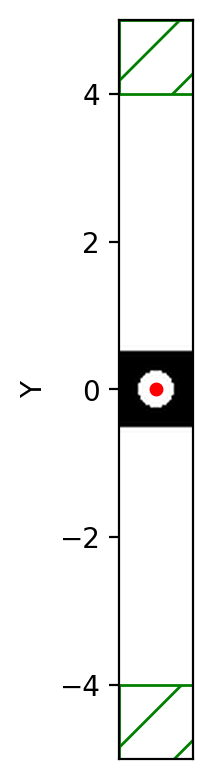

In [2]:
# Seemed to be common practice to define computational cell geometry like: 
sy = 10 
dpml = 1 
cell = mp.Vector3(1,sy)

# Parameters of waveguide
eps = 12
w = 1       
r = .25 

# Geometry: 
unitBlock = mp.Block(size = mp.Vector3(mp.inf, w, mp.inf ), material = mp.Medium(epsilon = eps))
    # Here defining the material for the holes is not necessary, but I wanted to include this here for myself as a reminder of the workflow
hole = mp.Cylinder(radius = r, material = mp.Medium(epsilon = 1))
geo = [unitBlock, hole]

res = 30
pml_layers = [mp.PML(dpml, direction = mp.Y)]

# Broad Gaussian to excite multiple modes as done in the ring example in the Meep Documentation: 
fcenter = 0.5
df = 1.5
src = mp.Source(mp.GaussianSource(fcenter, fwidth=df), mp.Ez, mp.Vector3())

sym = [mp.Mirror(direction=mp.Y, phase=-1)]

simulation = mp.Simulation(
    cell_size = cell, 
    geometry= geo, 
    sources = [src],
    resolution = res, 
    boundary_layers= pml_layers
)

f = plt.figure(dpi=200)
simulation.plot2D(ax = f.gca())
f.gca().xaxis.set_visible(False)
plt.show()


Illustration is how I wanted it to be, now we run and find the modes: utilizing the Harminv method from MIT

In [3]:
h = mp.Harminv(mp.Ez, mp.Vector3(), fcenter, df)

simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Broad_excitation.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.48363e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0146708 s
-----------
creating output file "./eps-000000.00.h5"...
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv0:, 0.20861586939286417, 2.7735768374334703e-08, -3760773.211278814, 0.014830350746338055, 0.0048280357145296165-0.014022459641540645i, 6.308175909941201e-07+0.0i
harminv0:, 0.4096860649767076, 5.863495118561157e-07, -349353.12189467676, 0.03485269983736467, 0.02371147866006449+0.0255436188843074i, 3.889738315038264e-08+0.0i
harminv0:, 0.5287319312725424, -0.00127048773354

Initially, wasn't getting anything that looked right. Changed the singal excitation to be broader to get the video above. Looking at specific Resonant Modes: 

In [4]:
# print(h.modes[0].freq)

simulation.reset_meep()
fcenter = h.modes[0].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3())
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/First_Mode.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 7.00951e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.014535 s
-----------
run 2 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 3 finished at t = 625.0 (37500 timesteps)
Generating MP4...


In [5]:


simulation.reset_meep()
fcenter = h.modes[1].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3())
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Second_Mode.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.6982e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.014457 s
-----------
run 4 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 5 finished at t = 625.0 (37500 timesteps)
Generating MP4...


In [6]:
simulation.reset_meep()
fcenter = h.modes[2].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3())
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Third_Mode.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.50747e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0146339 s
-----------
run 6 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 7 finished at t = 625.0 (37500 timesteps)
Generating MP4...


We can now find the photonic bands, I follow the holey-wvg-bands provided by Meep's Documentation: 

In [7]:
# The code below this cell is from holey-wvg-bands.ipynb from Meep Documentation
fcenter = .25
df = 1.5

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3())
]

In [9]:

simulation.restart_fields()
k_interp = 29
kpts = mp.interpolate(k_interp, [mp.Vector3(0), mp.Vector3(0.5)])
all_freqs = simulation.run_k_points(300, kpts)

harminv18:, frequency, imag. freq., Q, |amp|, amplitude, error
run 18 finished at t = 315.0 (18900 timesteps)
freqs:, 1, 0.0, 0.0, 0.0, 
freqs-im:, 1, 0.0, 0.0, 0.0, 
harminv19:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv19:, 0.015357777338093079, 3.297249401783859e-05, -232.88771134182787, 0.00026917506925074736, -0.00020067429202529847+0.0001794019131065493i, 7.563364856606381e-05+0.0i
harminv19:, 0.3364331692628638, -0.0002109148933165535, 797.5566921154427, 0.004961428151856337, 0.004909395118542078+0.0007166651073324331i, 8.613808476861249e-08+0.0i
harminv19:, 0.48118918204754546, -3.755328227884212e-05, 6406.752657125954, 0.000548018853045781, 0.0004611740278456007-0.00029604590747767226i, 4.847108026139533e-07+0.0i
run 19 finished at t = 315.0 (18900 timesteps)
freqs:, 2, 0.016666666666666666, 0.0, 0.0, 0.015357777338093079, 0.3364331692628638, 0.48118918204754546
freqs-im:, 2, 0.016666666666666666, 0.0, 0.0, 3.297249401783859e-05, -0.0002109148933165535, -3.7553

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_810936/2760698329.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_810936/2760698329.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


0.016666666666666666 0.015357777338093079
0.016666666666666666 0.3364331692628638
0.016666666666666666 0.48118918204754546
0.03333333333333333 0.33569605952316983
0.03333333333333333 0.480731956195327
0.05 0.03464752866952613
0.05 0.3345687292133963
0.05 0.47998981544801045
0.06666666666666667 0.06658640740226432
0.06666666666666667 0.3331980421700195
0.06666666666666667 0.3908056075043126
0.06666666666666667 0.4789933592976994
0.08333333333333333 0.04497455592244308
0.08333333333333333 0.05251143668778283
0.08333333333333333 0.08358738162228663
0.08333333333333333 0.3931974707813139
0.08333333333333333 0.4777831111774066
0.1 0.058492751939161466
0.1 0.3958699045104042
0.1 0.47640482951022556
0.11666666666666667 0.06527561069230994
0.11666666666666667 0.1185482140005592
0.11666666666666667 0.39873045844215144
0.11666666666666667 0.47491886686504126
0.13333333333333333 0.07159847134598972
0.13333333333333333 0.4016983576078723
0.13333333333333333 0.47335343008403713
0.15 0.0775816827911

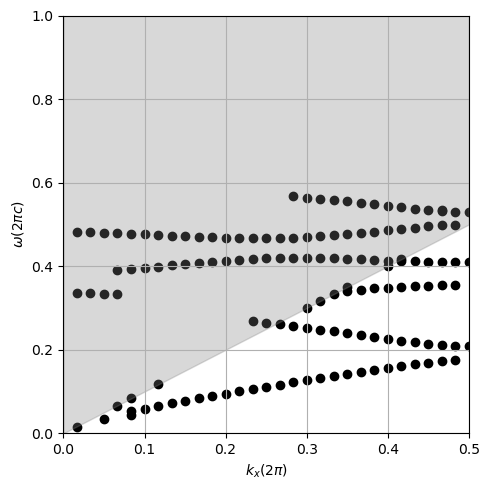

In [ ]:
kx = [k.x for k in kpts]
fig = plt.figure(dpi=100, figsize=(5, 5))
ax = plt.subplot(111)
for i in range(len(all_freqs)):
    for ii in range(len(all_freqs[i])):
        plt.scatter(kx[i], np.real(all_freqs[i][ii]), color="k")
        print(kx[i], np.real(all_freqs[i][ii]) )

ax.fill_between(kx, kx, 1.0, interpolate=True, color="gray", alpha=0.3)
plt.xlim(0, 0.5)
plt.ylim(0, 1)
plt.grid(True)
plt.xlabel("$k_x(2\pi)$")
plt.ylabel("$\omega(2\pi c)$")
plt.tight_layout()
plt.show()


In [ ]:
def run_sim(kx, omega, filename):
    s = [
        mp.Source(
            src=mp.GaussianSource(omega, fwidth=0.01),
            component=mp.Ez,
            center=mp.Vector3(),
        )
    ]
    sim = mp.Simulation(
        cell_size=cell,
        geometry=geo,
        boundary_layers=pml_layers,
        sources=s,
        symmetries=sym,
        k_point=mp.Vector3(kx),
        resolution=res,
    )
    f = plt.figure(dpi=100)
    animate = mp.Animate2D(fields=mp.Hz, f=f, normalize=True, realtime=False)
    sim.run(mp.at_every(.5, animate), until=50)
    animate.to_mp4(5, filename)
    plt.close()

In [ ]:
kx = [.1, .2, .417]
omega = [.098, 0.158, .583  ]
filename = [
    "Media/UnitCellbands-{}-{}.mp4".format(k, om) for (k, om) in zip(kx, omega)
]
for (k, om, fn) in zip(kx, omega, filename):
    run_sim(*[k, om, fn])

-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.00054884 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00793886 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000482798 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00755906 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000439882 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00740194 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...


In [ ]:
import IPython

for i in range(len(filename)):
    IPython.display.display(IPython.display.Video(filename[i]))

Now instead of exciting the center, whichh did not yield the results i wanted, I will excite the inner edge of the cell:  

In [ ]:
simulation.reset_meep()
fcenter = .25
df = 1.5
h = mp.Harminv(mp.Ez, mp.Vector3(0, r+.1), fcenter, df)

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,r+.1))
]

simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Broad_excitation2.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 6.81877e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0151281 s
-----------
Meep: using complex fields.
creating output file "./eps-000000.00.h5"...
harminv39:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv39:, 0.20861636865398517, 5.423475480187041e-09, -19232719.813715335, 0.3423639306314401, 0.3130331428194824-0.13864816080268455i, 7.331505724821934e-10+0.0i
harminv39:, 0.25747123042376663, 1.680840454585351e-09, -76590026.6504719, 0.5646410967339561, -0.5156061287111577-0.23015188062759298i, 4.146636454262627e-10+0.0i
harminv39:, 0.4096862437

/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1173: RuntimeWarning: Harminv frequency 1.0 is outside maximum Source frequency 0.5833333333333333
  warnings.warn(warn_fmt.format(harminv_max, sf_max), RuntimeWarning)
/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1176: RuntimeWarning: Harminv frequency -0.5 is outside minimum Source frequency -0.08333333333333331
  warnings.warn(warn_fmt.format(harminv_min, sf_min), RuntimeWarning)


Normalizing field data...
run 40 finished at t = 440.0 (26400 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[0].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,r+.1))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/First_Mode2.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 7.70092e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0144289 s
-----------
Meep: using complex fields.
run 41 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 42 finished at t = 625.0 (37500 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[1].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,r+.1))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Second_Mode2.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.29289e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.015785 s
-----------
Meep: using complex fields.
run 43 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 44 finished at t = 625.0 (37500 timesteps)
Generating MP4...


Now on the outside edge

In [ ]:
simulation.reset_meep()
fcenter = .25
df = 1.5
h = mp.Harminv(mp.Ez, mp.Vector3(0, w/2), fcenter, df)

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,w/2))
]

simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Broad_excitation3.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.50747e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0172782 s
-----------
Meep: using complex fields.
creating output file "./eps-000000.00.h5"...
harminv45:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv45:, 0.20861634329617304, -5.874859803928019e-09, 17755006.09875737, 0.2110144044239031, 0.19293378557331692-0.08546129684672416i, 1.6809406104078505e-09+0.0i
harminv45:, 0.25747124565339236, -5.8229669338983235e-09, 22108252.423221484, 0.4476463971136103, -0.40876803498601916-0.1824718894034496i, 6.32629009988335e-10+0.0i
harminv45:, 0.4096863

/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1173: RuntimeWarning: Harminv frequency 1.0 is outside maximum Source frequency 0.5833333333333333
  warnings.warn(warn_fmt.format(harminv_max, sf_max), RuntimeWarning)
/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1176: RuntimeWarning: Harminv frequency -0.5 is outside minimum Source frequency -0.08333333333333331
  warnings.warn(warn_fmt.format(harminv_min, sf_min), RuntimeWarning)


run 46 finished at t = 440.0 (26400 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[0].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,w/2))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/First_Mode3.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.98431e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0145662 s
-----------
Meep: using complex fields.
run 47 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 48 finished at t = 625.0 (37500 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[1].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,w/2))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Second_Mode3.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 4.98295e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0145578 s
-----------
Meep: using complex fields.
run 49 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 50 finished at t = 625.0 (37500 timesteps)
Generating MP4...


In [ ]:
# The code below this cell is from holey-wvg-bands.ipynb from Meep Documentation
fcenter = .25
df = 1.5

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(0,w))
]

In [ ]:
%%capture
simulation.restart_fields()
k_interp = 29
kpts = mp.interpolate(k_interp, [mp.Vector3(0), mp.Vector3(0.5)])
all_freqs = simulation.run_k_points(300, kpts)

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_810936/3930202032.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_810936/3930202032.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


0.0 0.37893774826688087
0.016666666666666666 0.015125664424102361
0.016666666666666666 0.33672373365570757
0.016666666666666666 0.37145208452892736
0.016666666666666666 0.38126818474165275
0.016666666666666666 0.4829808176914998
0.016666666666666666 0.5780119926834968
0.03333333333333333 0.33235840161578184
0.03333333333333333 0.36748329940170027
0.03333333333333333 0.38537726324708077
0.03333333333333333 0.385938868429034
0.03333333333333333 0.48045606181860673
0.03333333333333333 0.5771634022771146
0.05 0.032051447813549426
0.05 0.3027582554747501
0.05 0.334538263814646
0.05 0.3637868253289867
0.05 0.37943640538043133
0.05 0.38941806929382583
0.05 0.48007577624680314
0.05 0.5761489094019501
0.06666666666666667 0.35941099753746425
0.06666666666666667 0.389743372770027
0.06666666666666667 0.3933540972101323
0.06666666666666667 0.47926401691185644
0.06666666666666667 0.57452025634093
0.08333333333333333 0.052592278264936496
0.08333333333333333 0.3293610168622464
0.08333333333333333 0.35

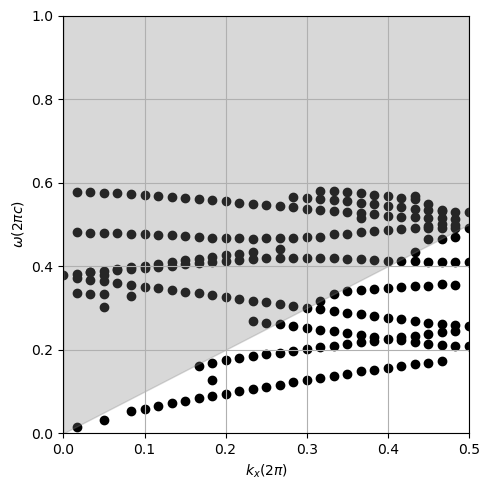

In [ ]:
kx = [k.x for k in kpts]
fig = plt.figure(dpi=100, figsize=(5, 5))
ax = plt.subplot(111)
for i in range(len(all_freqs)):
    for ii in range(len(all_freqs[i])):
        plt.scatter(kx[i], np.real(all_freqs[i][ii]), color="k")
        print(kx[i], np.real(all_freqs[i][ii]) )

ax.fill_between(kx, kx, 1.0, interpolate=True, color="gray", alpha=0.3)
plt.xlim(0, 0.5)
plt.ylim(0, 1)
plt.grid(True)
plt.xlabel("$k_x(2\pi)$")
plt.ylabel("$\omega(2\pi c)$")
plt.tight_layout()
plt.show()

In [ ]:
def run_sim(kx, omega, filename):
    s = [
        mp.Source(
            src=mp.GaussianSource(omega, fwidth=0.1),
            component=mp.Ez,
            center=mp.Vector3(0,w/2),
        )
    ]
    sim = mp.Simulation(
        cell_size=cell,
        geometry=geo,
        boundary_layers=pml_layers,
        sources=s,
        symmetries=sym,
        k_point=mp.Vector3(kx),
        resolution=res,
    )
    f = plt.figure(dpi=100)
    animate = mp.Animate2D(fields=mp.Hz, f=f, normalize=True, realtime=False)
    sim.run(mp.at_every(.5, animate), until=50)
    animate.to_mp4(5, filename)
    plt.close()

kx = [0.25, 0.21666666666666667, .1]
omega = [0.18933936494043174, 0.5769475402861698, 0.09848877411891024  ]
filename = [
    "Media/UnitCellbands-{}-{}.mp4".format(k, om) for (k, om) in zip(kx, omega)
]
for (k, om, fn) in zip(kx, omega, filename):
    run_sim(*[k, om, fn])

-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000615835 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00783896 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000487089 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0100622 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...
-----------
Initializing structure...
Halving computational cell along direction y
time for choose_chunkdivision = 0.000481129 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00750399 s
-----------
Meep: using complex fields.
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...


/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/visualization.py:1582: RuntimeWarning: invalid value encountered in divide
  fields = np.array(self.cumulative_fields) / np.max(


run 0 finished at t = 50.0 (3000 timesteps)
Generating MP4...


In [ ]:
import IPython

for i in range(len(filename)):
    IPython.display.display(IPython.display.Video(filename[i]))

Still not what I want: 

In [ ]:
simulation.reset_meep()
fcenter = .25
df = 1.5
h = mp.Harminv(mp.Ez, mp.Vector3(w/6, 0), fcenter, df)

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(w/6,0))
]

simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until = 25)

plt.close()

filename = "Media/Broad_excitation4.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.79357e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0148039 s
-----------
Meep: using complex fields.
creating output file "./eps-000000.00.h5"...
harminv82:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv82:, 0.17552361144400488, 2.3214306693812648e-08, -3780505.1376095484, 0.048590870773549635, 0.020103874288849934+0.044236941136452i, 7.333453059418507e-09+0.0i
harminv82:, 0.20861635958033353, 2.6258956298346565e-09, -39722896.296809286, 0.226118669530351, 0.2067457299981067-0.09157431865826822i, 1.1893647054313928e-09+0.0i
harminv82:, 0.35517

/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1173: RuntimeWarning: Harminv frequency 1.0 is outside maximum Source frequency 0.5833333333333333
  warnings.warn(warn_fmt.format(harminv_max, sf_max), RuntimeWarning)
/home/kit/miniconda3/envs/mp/lib/python3.13/site-packages/meep/simulation.py:1176: RuntimeWarning: Harminv frequency -0.5 is outside minimum Source frequency -0.08333333333333331
  warnings.warn(warn_fmt.format(harminv_min, sf_min), RuntimeWarning)


run 83 finished at t = 440.0 (26400 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[0].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(w/6,0))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until=50)

plt.close()

filename = "Media/First_Mode4.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 5.60284e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.01478 s
-----------
Meep: using complex fields.
run 84 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 85 finished at t = 650.0 (39000 timesteps)
Generating MP4...


In [ ]:
simulation.reset_meep()
fcenter = h.modes[2].freq
df = 0.05 

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(w/6,0))
]

simulation.run(until = 600)

f = plt.figure(dpi = 150) 
f.gca().xaxis.set_visible(False)
Animate = mp.Animate2D(fields = mp.Ez, f = f, realtime = False, normalize = True)
simulation.run(mp.at_every(.5,Animate), until=50)

plt.close()

filename = "Media/First_Mode4.mp4"
Animate.to_mp4(5,filename)
Video(filename)

-----------
Initializing structure...
time for choose_chunkdivision = 6.58035e-05 s
Working in 2D dimensions.
Computational cell is 1 x 10 x 0 with resolution 30
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.0148702 s
-----------
Meep: using complex fields.
run 86 finished at t = 600.0 (36000 timesteps)
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
Normalizing field data...
run 87 finished at t = 650.0 (39000 timesteps)
Generating MP4...


In [ ]:
# The code below this cell is from holey-wvg-bands.ipynb from Meep Documentation
fcenter = .25
df = 1.5

simulation.sources = [
    mp.Source(mp.GaussianSource(fcenter, df), mp.Ez, mp.Vector3(w/6,0))
]

In [ ]:
%%capture
simulation.restart_fields()
k_interp = 19
kpts = mp.interpolate(k_interp, [mp.Vector3(0), mp.Vector3(0.5)])
all_freqs = simulation.run_k_points(800, kpts)

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_810936/3930202032.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_810936/3930202032.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


0.0 0.3367149845626216
0.0 0.48138316169957385
0.025 0.33617248927056836
0.025 0.4810131220528206
0.05 0.02226215770130844
0.05 0.034082738016351505
0.05 0.334587810091548
0.05 0.38933594092300455
0.05 0.4799870735344561
0.07500000000000001 0.048768712416137325
0.07500000000000001 0.4787668104167547
0.1 0.058524825638533194
0.1 0.4766424238377976
0.125 0.06851070095794876
0.125 0.400405947093318
0.125 0.4741370822072873
0.15000000000000002 0.07676338869951277
0.15000000000000002 0.40276043227602826
0.15000000000000002 0.47362077279043213
0.17500000000000002 0.0863243426219288
0.17500000000000002 0.40564431697076353
0.17500000000000002 0.4090780716476736
0.17500000000000002 0.46956085376408574
0.17500000000000002 0.5569021269706056
0.2 0.09484008281200751
0.2 0.41309756461452835
0.2 0.46786779666233475
0.225 0.10302063145254803
0.225 0.41653491824789235
0.225 0.46503080326373797
0.25 0.11117774148344392
0.25 0.4190030109204054
0.275 0.11925546164024492
0.275 0.25883629378818207
0.275 0.

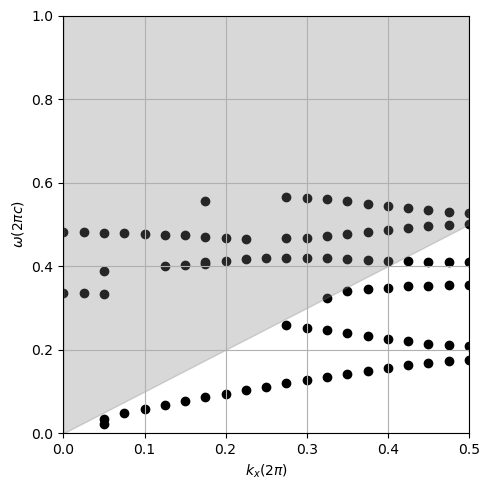

In [ ]:
kx = [k.x for k in kpts]
fig = plt.figure(dpi=100, figsize=(5, 5))
ax = plt.subplot(111)
for i in range(len(all_freqs)):
    for ii in range(len(all_freqs[i])):
        plt.scatter(kx[i], np.real(all_freqs[i][ii]), color="k")
        print(kx[i], np.real(all_freqs[i][ii]) )

ax.fill_between(kx, kx, 1.0, interpolate=True, color="gray", alpha=0.3)
plt.xlim(0, 0.5)
plt.ylim(0, 1)
plt.grid(True)
plt.xlabel("$k_x(2\pi)$")
plt.ylabel("$\omega(2\pi c)$")
plt.tight_layout()
plt.show()